Problem statement:- For this assessment, you will work with the Candy Preference Dataset (candy.csv). Dataset is uploaded on the LMS portal
The dataset contains information about different candy characteristics such as chocolate, fruity flavor, sugar content, price percentile, and popularity (win percentage).
Each row represents a single candy product, and the columns describe its attributes.
Most feature columns are binary variables (0 = No, 1 = Yes) representing whether a candy has a specific ingredient or property.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pandas is used for loading and manipulating datasets.
# NumPy is used for numerical operations.
# Matplotlib is used to create charts and graphs.
# Seaborn is used to create attractive statistical visualizations.

In [3]:
df = pd.read_csv("/content/sample_data/candy.csv")
df.head()

# The head() function displays the first five rows of the dataset.

,id,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,0,100 Grand,Yes,No,Yes,No,No,Yes,No,Yes,No,0.732,0.860,66.971725
1,1,3 Musketeers,Yes,No,No,No,Yes,No,No,Yes,No,0.604,0.511,67.602936
2,2,Air Heads,No,Yes,No,No,No,No,No,No,No,0.906,0.511,52.341465
3,3,Almond Joy,Yes,No,No,Yes,No,No,No,Yes,No,0.465,0.767,50.347546
4,4,Baby Ruth,Yes,No,Yes,Yes,Yes,No,No,Yes,No,0.604,0.767,56.914547


In [ ]:
df.shape

# The dataset contains 83 rows 14 columns

(83, 14)

In [ ]:
df.info()

# provide information about dataset number of row colmns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                83 non-null     int64  
 1   competitorname    83 non-null     object 
 2   chocolate         83 non-null     object 
 3   fruity            83 non-null     object 
 4   caramel           83 non-null     object 
 5   peanutyalmondy    83 non-null     object 
 6   nougat            83 non-null     object 
 7   crispedricewafer  83 non-null     object 
 8   hard              83 non-null     object 
 9   bar               83 non-null     object 
 10  pluribus          83 non-null     object 
 11  sugarpercent      83 non-null     float64
 12  pricepercent      83 non-null     float64
 13  winpercent        83 non-null     float64
dtypes: float64(3), int64(1), object(10)
memory usage: 9.2+ KB


In [ ]:
df.dtypes
# Data Types

,0
id,int64
competitorname,object
chocolate,object
fruity,object
caramel,object
peanutyalmondy,object
nougat,object
crispedricewafer,object
hard,object
bar,object


In [ ]:
df.isnull().sum()

# Check Missing Values in the dataset

,0
id,0
competitorname,0
chocolate,0
fruity,0
caramel,0
peanutyalmondy,0
nougat,0
crispedricewafer,0
hard,0
bar,0


In [ ]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [ ]:
# Statistical Summary

df.describe()

,id,sugarpercent,pricepercent,winpercent
count,83.000000,83.000000,83.000000,83.000000
mean,41.000000,0.489916,0.472627,50.584908
std,24.103942,0.276498,0.286503,14.748880
min,0.000000,0.034000,0.011000,22.445341
25%,20.500000,0.267000,0.261000,39.163280
50%,41.000000,0.465000,0.465000,48.982651
75%,61.500000,0.732000,0.703000,60.332349
max,82.000000,0.988000,0.976000,84.180290


In [ ]:
# Unique Values
df.nunique()


,0
id,83
competitorname,83
chocolate,2
fruity,2
caramel,2
peanutyalmondy,2
nougat,2
crispedricewafer,2
hard,2
bar,2


In [4]:
# Check Data Types
df.dtypes

,0
id,int64
competitorname,object
chocolate,object
fruity,object
caramel,object
peanutyalmondy,object
nougat,object
crispedricewafer,object
hard,object
bar,object


In [15]:
Q1 = df['pricepercent'].quantile(0.25)
Q3 = df['pricepercent'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df['pricepercent'] < lower_limit) | (df['pricepercent'] > upper_limit)]
print("Number of Outliers:", outliers.shape[0])
outliers[['competitorname', 'pricepercent']].head(10)

Number of Outliers: 0


,competitorname,pricepercent


In [5]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['competitorname', 'chocolate', 'fruity', 'caramel', 'peanutyalmondy',
       'nougat', 'crispedricewafer', 'hard', 'bar', 'pluribus'],
      dtype='object')


In [11]:
# Convert Categorical Columns to Numerical Using Label Encoding

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()
df['chocolate'] = le.fit_transform(df['chocolate'])
df['fruity'] = le.fit_transform(df['fruity'])
df['caramel'] = le.fit_transform(df['caramel'])
df['peanutyalmondy'] = le.fit_transform(df['peanutyalmondy'])
df['crispedricewafer'] = le.fit_transform(df['crispedricewafer'])
df['nougat'] = le.fit_transform(df['nougat'])
df['hard'] = le.fit_transform(df['hard'])
df['bar'] = le.fit_transform(df['bar'])
df['pluribus'] = le.fit_transform(df['pluribus'])
df

,id,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,2,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465
3,3,Almond Joy,1,0,0,1,0,0,0,1,0,0.465,0.767,50.347546
4,4,Baby Ruth,1,0,1,1,1,0,0,1,0,0.604,0.767,56.914547
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,78,Twizzlers,0,1,0,0,0,0,0,0,0,0.220,0.116,45.466282
79,79,Warheads,0,1,0,0,0,0,1,0,0,0.093,0.116,39.011898
80,80,Welch's Fruit Snacks,0,1,0,0,0,0,0,0,1,0.313,0.313,44.375519
81,81,Werther's Original Caramel,0,0,1,0,0,0,1,0,0,0.186,0.267,41.904308


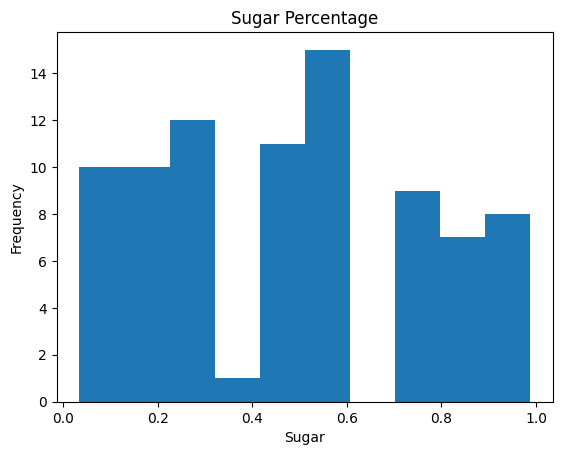

In [16]:
# Univariate analysis
# Sugar Percentage Histogram

plt.hist(df['sugarpercent'],bins=10)

plt.title("Sugar Percentage")

plt.xlabel("Sugar")

plt.ylabel("Frequency")

plt.show()

id


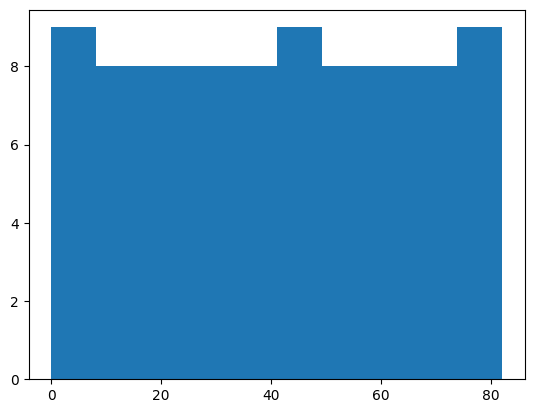

competitorname


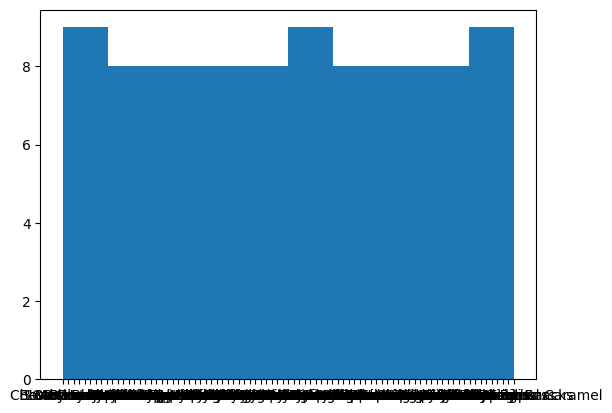

chocolate


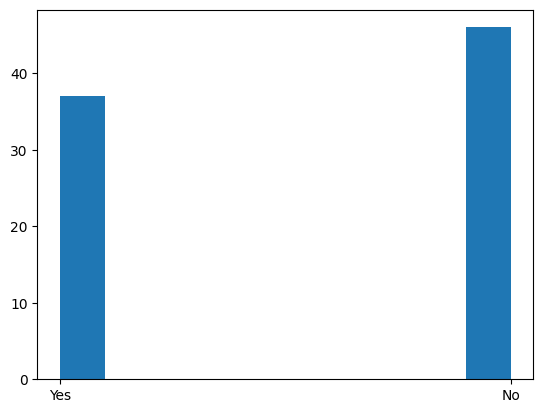

fruity


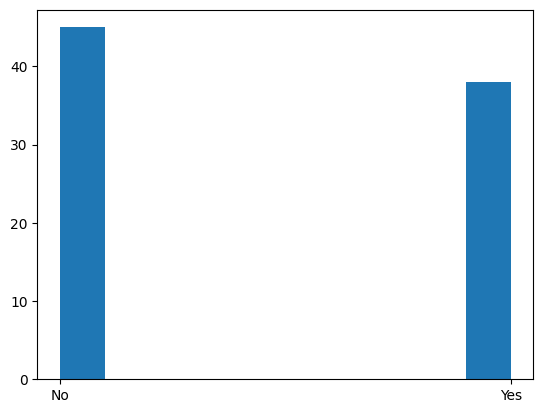

caramel


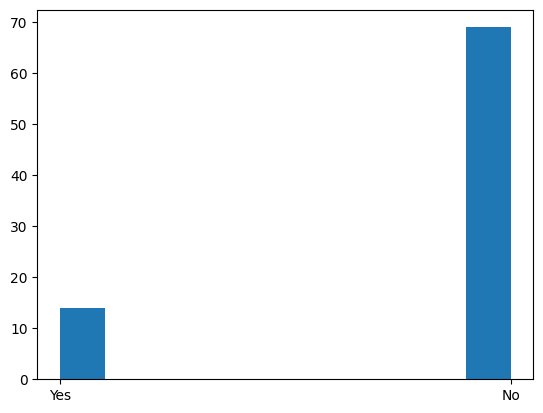

peanutyalmondy


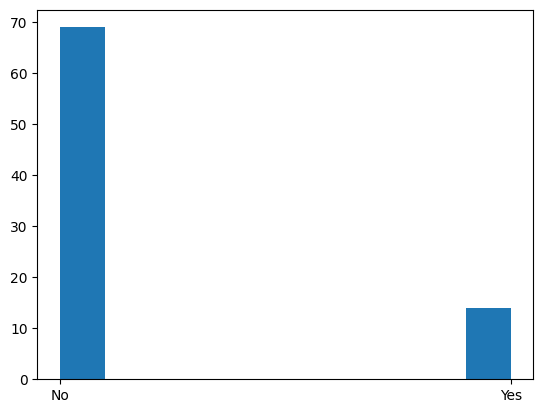

nougat


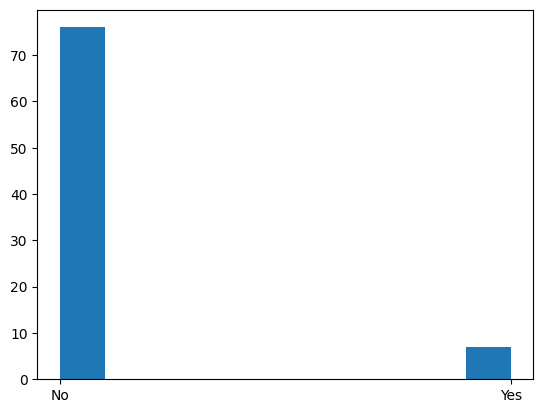

crispedricewafer


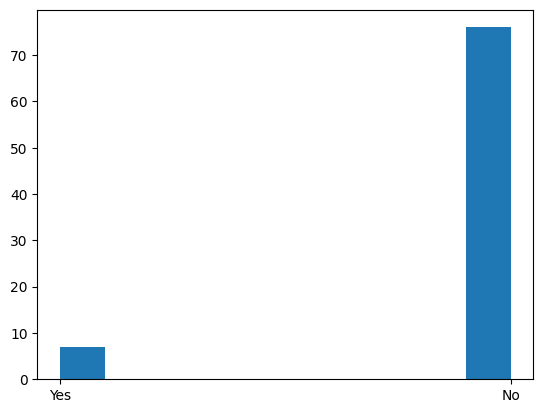

hard


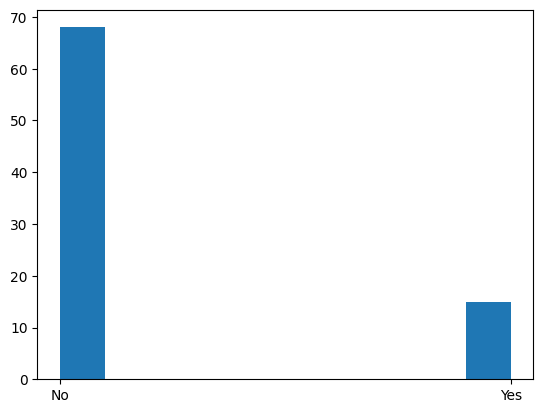

bar


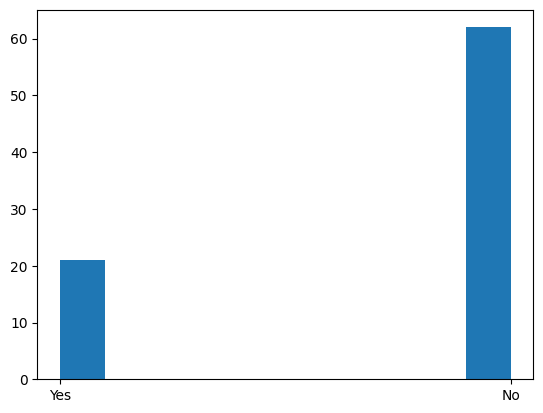

pluribus


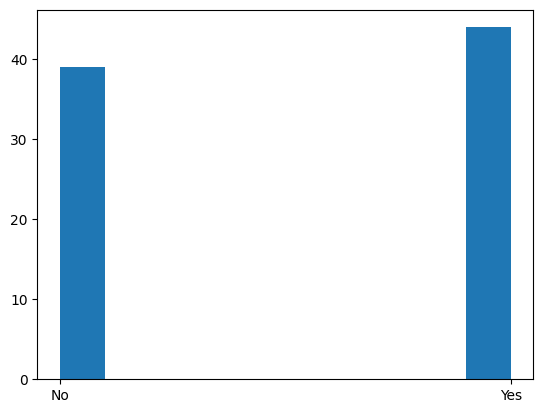

sugarpercent


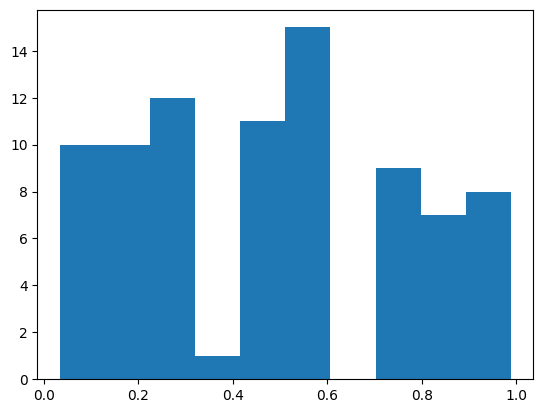

pricepercent


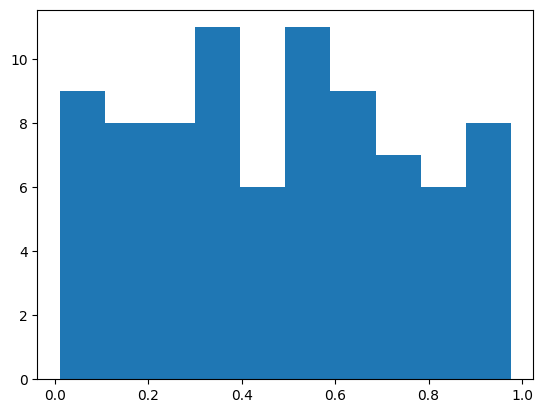

winpercent


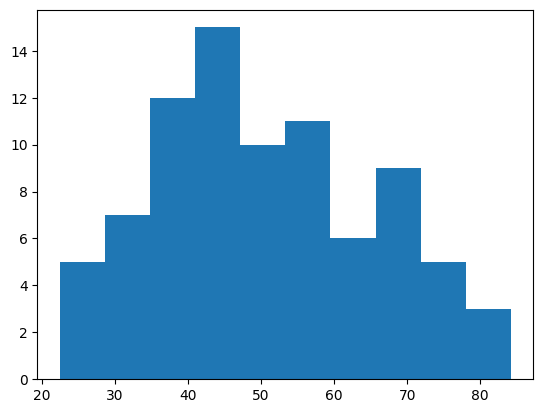

In [ ]:
for i in df:
  print(i)
  plt.hist(df[i])
  plt.show()

In [ ]:
# ID column was removed because it only identifies each candy and does not provide any useful information for the analysis.
df = df.drop('id', axis=1)

In [17]:
# Bivariate analysis

df.corr(numeric_only=True)

,id,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
id,1.000000,-0.013152,0.022206,0.065804,-0.051032,-0.179153,0.041621,0.115008,-0.197804,0.064486,-0.148374,-0.158402,0.043226
chocolate,-0.013152,1.000000,-0.775500,0.243325,0.372786,0.251167,0.338392,-0.358230,0.593165,-0.369810,0.072069,0.502438,0.632373
fruity,0.022206,-0.775500,1.000000,-0.349349,-0.413928,-0.278887,-0.278887,0.385407,-0.534810,0.283713,-0.073631,-0.451413,-0.405264
caramel,0.065804,0.243325,-0.349349,1.000000,0.054865,0.326416,0.210636,-0.127943,0.329919,-0.285049,0.211804,0.251414,0.207772
peanutyalmondy,-0.051032,0.372786,-0.413928,0.054865,1.000000,0.210636,-0.020924,-0.211559,0.255910,-0.220583,0.072723,0.306888,0.402892
nougat,-0.179153,0.251167,-0.278887,0.326416,0.210636,1.000000,-0.092105,-0.142539,0.521469,-0.322356,0.115097,0.150817,0.195987
crispedricewafer,0.041621,0.338392,-0.278887,0.210636,-0.020924,-0.092105,1.000000,-0.142539,0.421741,-0.235488,0.060040,0.327728,0.322650
hard,0.115008,-0.358230,0.385407,-0.127943,-0.211559,-0.142539,-0.142539,1.000000,-0.273341,0.003023,0.076022,-0.253483,-0.322812
bar,-0.197804,0.593165,-0.534810,0.329919,0.255910,0.521469,0.421741,-0.273341,1.000000,-0.618170,0.080044,0.517721,0.425203
pluribus,0.064486,-0.369810,0.283713,-0.285049,-0.220583,-0.322356,-0.235488,0.003023,-0.618170,1.000000,0.004191,-0.239779,-0.272584


<Axes: >

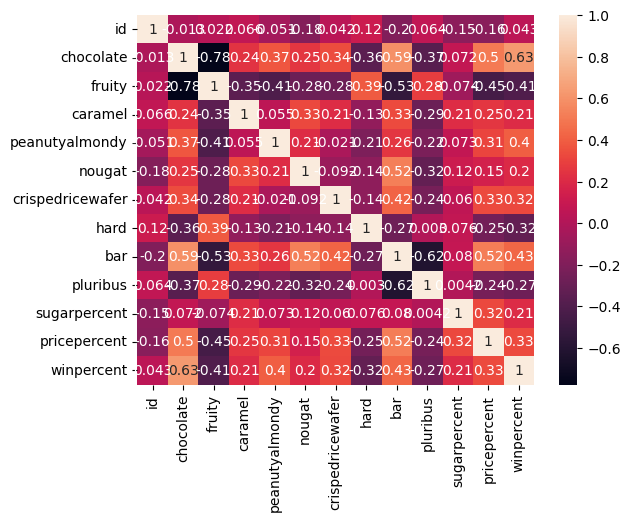

In [18]:
## heatmap

sns.heatmap(df.corr(numeric_only=True), annot=True)